# Phase 2: Core Simulation Engine — Validation Suite

This notebook provides **actionable validation** of Phase 2 implementation with:
- **Forced scenarios** that trigger each mechanism
- **Clear assertions** with expected vs actual outcomes
- **Diagnostic outputs** explaining pass/fail results

In [1]:
# Cell 1: Setup and Imports

import sys
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Ensure project root is in path
project_root = os.path.abspath(os.path.join(os.getcwd(), '..'))
if project_root not in sys.path:
    sys.path.insert(0, project_root)

# Import modules
from src.data_loader import fetch_and_cache_market_data, engineer_features
from src.graph_builder import build_graph_for_timestep
from src.simulation import FinancialSystem, SimulationEvent
from src.agents import BankAgent, ExchangeNode, CCP_Controller
from src.config import (
    BANK_TICKERS, EXCHANGE_TICKERS,
    VIX_HALT_THRESHOLD, CONTAGION_LOSS_FACTOR, DEFAULT_INITIAL_CASH
)

print("✅ All modules imported")
print(f"\n📋 Test Configuration:")
print(f"   VIX Halt Threshold: {VIX_HALT_THRESHOLD}")
print(f"   Contagion Loss Factor: {CONTAGION_LOSS_FACTOR}")
print(f"   Banks under test: {len(BANK_TICKERS)}")

# Test result tracking
test_results = []

✅ All modules imported

📋 Test Configuration:
   VIX Halt Threshold: 40.0
   Contagion Loss Factor: 0.1
   Banks under test: 6


In [2]:
# Cell 2: Load Data

print("--- Loading Market Data ---")
raw_data = fetch_and_cache_market_data(start_date='2005-08-08', end_date='2022-08-08')
processed_data = engineer_features(raw_data)

print(f"\n✅ Data loaded: {processed_data.shape[0]} rows, {processed_data.shape[1]} columns")
print(f"   Date range: {processed_data.index.min()} to {processed_data.index.max()}")

--- Loading Market Data ---
Loading historical data from cache: data/historical_market_data_INDIA.pkl
Starting feature engineering...
Feature engineering complete.

✅ Data loaded: 5015 rows, 15 columns
   Date range: 2013-02-13 00:00:00 to 2022-08-05 00:00:00


In [3]:
# Cell 3: TEST 1 — System Initialization

print("=" * 60)
print("TEST 1: SYSTEM INITIALIZATION")
print("=" * 60)

# Create the system
system = FinancialSystem(
    processed_data=processed_data,
    initial_bank_cash=1_000_000_000,
    ccp_default_fund=10_000_000_000,
    ccp_risk_aversion=0.5
)

# Assertions (updated for June-August 2022 date range)
assertions = [
    ("Banks created", len(system.banks) == len(BANK_TICKERS), len(system.banks), len(BANK_TICKERS)),
    ("Exchanges created", len(system.exchanges) == len(EXCHANGE_TICKERS), len(system.exchanges), len(EXCHANGE_TICKERS)),
    ("CCP initialized", system.ccp.default_fund == 10_000_000_000, f"₹{system.ccp.default_fund:,.0f}", "₹10,000,000,000"),
    ("All banks active", all(not b.is_defaulted for b in system.banks.values()), "All active", "All active"),
    ("All exchanges open", all(e.is_open for e in system.exchanges.values()), "All open", "All open"),
    ("Available dates", len(system.available_dates) > 30, len(system.available_dates), "> 30"),
]

print("\n" + "-" * 60)
print(f"{'Check':<30} {'Result':<8} {'Actual':<20} {'Expected':<20}")
print("-" * 60)

test1_pass = True
for name, passed, actual, expected in assertions:
    status = "✅ PASS" if passed else "❌ FAIL"
    if not passed:
        test1_pass = False
    print(f"{name:<30} {status:<8} {str(actual):<20} {str(expected):<20}")

print("-" * 60)
print(f"\n{'✅ TEST 1 PASSED' if test1_pass else '❌ TEST 1 FAILED'}")
test_results.append(("Initialization", test1_pass))

TEST 1: SYSTEM INITIALIZATION
✅ FinancialSystem initialized:
   Banks: 6
   Exchanges: 2
   CCP Default Fund: ₹10,000,000,000
   Available dates: 526 trading days

------------------------------------------------------------
Check                          Result   Actual               Expected            
------------------------------------------------------------
Banks created                  ✅ PASS   6                    6                   
Exchanges created              ✅ PASS   2                    2                   
CCP initialized                ✅ PASS   ₹10,000,000,000      ₹10,000,000,000     
All banks active               ✅ PASS   All active           All active          
All exchanges open             ✅ PASS   All open             All open            
Available dates                ✅ PASS   526                  > 30                
------------------------------------------------------------

✅ TEST 1 PASSED


In [4]:
# Cell 4: TEST 2 — Trade Execution (Forced Scenario)

print("=" * 60)
print("TEST 2: TRADE EXECUTION (Forced Sell Scenario)")
print("=" * 60)

system.reset()

# FORCE a trade by giving a bank portfolio and reducing its cash
test_bank = system.banks['HDFCBANK.NS']
print(f"\n📊 Setting up forced trade scenario for {test_bank.ticker}:")

# Give the bank some portfolio to sell
test_bank.portfolio = {'RELIANCE.NS': 10000}  # 10,000 shares of Reliance
test_bank.available_cash = 50_000_000  # Low cash (₹5 crore) to trigger sell

print(f"   Initial Portfolio: {test_bank.portfolio}")
print(f"   Initial Cash: ₹{test_bank.available_cash:,.0f}")

# Store initial state
initial_cash = test_bank.available_cash
initial_shares = test_bank.portfolio.get('RELIANCE.NS', 0)

# Run a step (use a date within the available range)
target_date = pd.Timestamp('2022-07-15')
step_result = system.step(target_date)

# Check results
final_cash = test_bank.available_cash
final_shares = test_bank.portfolio.get('RELIANCE.NS', 0)

print(f"\n📊 After step execution:")
print(f"   Final Portfolio: {test_bank.portfolio}")
print(f"   Final Cash: ₹{final_cash:,.0f}")
print(f"   Trades executed: {step_result['trades_executed']}")

# Assertions
cash_increased = final_cash > initial_cash
shares_decreased = final_shares < initial_shares
trade_logged = step_result['trades_executed'] >= 1

assertions = [
    ("Cash increased (sold assets)", cash_increased, f"₹{final_cash:,.0f}", f"> ₹{initial_cash:,.0f}"),
    ("Shares decreased (sold)", shares_decreased, f"{final_shares:,.0f}", f"< {initial_shares:,.0f}"),
    ("Trade logged in results", trade_logged, step_result['trades_executed'], ">= 1"),
]

print("\n" + "-" * 60)
print(f"{'Check':<30} {'Result':<8} {'Actual':<20} {'Expected':<20}")
print("-" * 60)

test2_pass = True
for name, passed, actual, expected in assertions:
    status = "✅ PASS" if passed else "❌ FAIL"
    if not passed:
        test2_pass = False
    print(f"{name:<30} {status:<8} {str(actual):<20} {str(expected):<20}")

# Show simulation log
trade_events = [e for e in system.simulation_log if 'TRADE' in e.event_type]
print(f"\n📝 Trade Events in Log: {len(trade_events)}")
for event in trade_events[:3]:
    print(f"   {event.event_type}: {event.details}")

print("-" * 60)
print(f"\n{'✅ TEST 2 PASSED' if test2_pass else '❌ TEST 2 FAILED'}")
test_results.append(("Trade Execution", test2_pass))

TEST 2: TRADE EXECUTION (Forced Sell Scenario)
🔄 System reset to initial state

📊 Setting up forced trade scenario for HDFCBANK.NS:
   Initial Portfolio: {'RELIANCE.NS': 10000}
   Initial Cash: ₹50,000,000

📊 After step execution:
   Final Portfolio: {'RELIANCE.NS': 8000.0}
   Final Cash: ₹50,200,000
   Trades executed: 1

------------------------------------------------------------
Check                          Result   Actual               Expected            
------------------------------------------------------------
Cash increased (sold assets)   ✅ PASS   ₹50,200,000          > ₹50,000,000       
Shares decreased (sold)        ✅ PASS   8,000                < 10,000            
Trade logged in results        ✅ PASS   1                    >= 1                

📝 Trade Events in Log: 2
   TRADE_DECISIONS: {'total': 6, 'sells': 1, 'holds': 5}
   TRADE_EXECUTED: {'bank': 'HDFCBANK.NS', 'action': 'SELL', 'asset': 'RELIANCE.NS', 'amount': 200000.0}
-------------------------------------

/Users/aryan/MACHINE-LEARNING/Pytho/venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [5]:
# Cell 5: TEST 3 — Default Detection

print("=" * 60)
print("TEST 3: DEFAULT DETECTION")
print("=" * 60)

system.reset()

# FORCE a default by setting negative cash
test_bank = system.banks['ICICIBANK.NS']
print(f"\n📊 Forcing default for {test_bank.ticker}:")

# Set negative cash to trigger default
test_bank.available_cash = -500_000_000  # -₹50 crore

print(f"   Cash set to: ₹{test_bank.available_cash:,.0f}")
print(f"   Is defaulted before step: {test_bank.is_defaulted}")

# Run a step
step_result = system.step(pd.Timestamp('2022-07-15'))

print(f"\n📊 After step execution:")
print(f"   Is defaulted now: {test_bank.is_defaulted}")
print(f"   Defaults in step: {step_result['defaults']}")

# Assertions
bank_marked_defaulted = test_bank.is_defaulted == True
default_in_results = 'ICICIBANK.NS' in step_result['defaults']

assertions = [
    ("Bank marked as defaulted", bank_marked_defaulted, test_bank.is_defaulted, True),
    ("Default in step results", default_in_results, step_result['defaults'], "Contains ICICIBANK.NS"),
]

print("\n" + "-" * 60)
print(f"{'Check':<30} {'Result':<8} {'Actual':<25} {'Expected':<25}")
print("-" * 60)

test3_pass = True
for name, passed, actual, expected in assertions:
    status = "✅ PASS" if passed else "❌ FAIL"
    if not passed:
        test3_pass = False
    print(f"{name:<30} {status:<8} {str(actual):<25} {str(expected):<25}")

# Show default events
default_events = [e for e in system.simulation_log if 'DEFAULT' in e.event_type]
print(f"\n📝 Default Events in Log: {len(default_events)}")
for event in default_events[:3]:
    print(f"   {event.event_type}: {event.details}")

print("-" * 60)
print(f"\n{'✅ TEST 3 PASSED' if test3_pass else '❌ TEST 3 FAILED'}")
test_results.append(("Default Detection", test3_pass))

TEST 3: DEFAULT DETECTION
🔄 System reset to initial state

📊 Forcing default for ICICIBANK.NS:
   Cash set to: ₹-500,000,000
   Is defaulted before step: False

📊 After step execution:
   Is defaulted now: True
   Defaults in step: ['ICICIBANK.NS']

------------------------------------------------------------
Check                          Result   Actual                    Expected                 
------------------------------------------------------------
Bank marked as defaulted       ✅ PASS   True                      True                     
Default in step results        ✅ PASS   ['ICICIBANK.NS']          Contains ICICIBANK.NS    

📝 Default Events in Log: 1
   BANK_DEFAULT: {'bank': 'ICICIBANK.NS', 'cash_shortfall': 500000000}
------------------------------------------------------------

✅ TEST 3 PASSED


In [6]:
# Cell 6: TEST 4 — Contagion Propagation

print("=" * 60)
print("TEST 4: CONTAGION PROPAGATION")
print("=" * 60)

system.reset()

# Record initial cash of all banks
initial_cash_all = {t: b.available_cash for t, b in system.banks.items()}
print(f"\n📊 Initial cash for all banks: ₹{initial_cash_all['HDFCBANK.NS']:,.0f}")

# FORCE a default to trigger contagion
defaulting_bank = 'SBIN.NS'
system.banks[defaulting_bank].available_cash = -1_000_000_000  # -₹100 crore loss
print(f"   Setting {defaulting_bank} cash to: ₹{system.banks[defaulting_bank].available_cash:,.0f}")

# Run a step
step_result = system.step(pd.Timestamp('2022-07-15'))

print(f"\n📊 After step execution:")
print(f"   Total contagion loss: ₹{step_result['total_contagion_loss']:,.0f}")
print(f"   CCP losses absorbed: ₹{system.ccp.total_losses_absorbed:,.0f}")

# Check which banks lost money
banks_affected = []
for ticker, bank in system.banks.items():
    if ticker != defaulting_bank:
        initial = initial_cash_all[ticker]
        current = bank.available_cash
        if current < initial:
            banks_affected.append((ticker, initial - current))

print(f"\n📊 Banks affected by contagion: {len(banks_affected)}")
for ticker, loss in banks_affected[:5]:
    print(f"   {ticker}: lost ₹{loss:,.0f}")

# Assertions
contagion_occurred = step_result['total_contagion_loss'] > 0
banks_lost_money = len(banks_affected) > 0
ccp_absorbed = system.ccp.total_losses_absorbed > 0

assertions = [
    ("Contagion loss > 0", contagion_occurred, f"₹{step_result['total_contagion_loss']:,.0f}", "> ₹0"),
    ("Neighboring banks lost money", banks_lost_money, len(banks_affected), "> 0"),
    ("CCP absorbed losses", ccp_absorbed, f"₹{system.ccp.total_losses_absorbed:,.0f}", "> ₹0"),
]

print("\n" + "-" * 60)
print(f"{'Check':<30} {'Result':<8} {'Actual':<25} {'Expected':<25}")
print("-" * 60)

test4_pass = True
for name, passed, actual, expected in assertions:
    status = "✅ PASS" if passed else "❌ FAIL"
    if not passed:
        test4_pass = False
    print(f"{name:<30} {status:<8} {str(actual):<25} {str(expected):<25}")

# Show contagion events
contagion_events = [e for e in system.simulation_log if 'CONTAGION' in e.event_type]
print(f"\n📝 Contagion Events in Log: {len(contagion_events)}")
for event in contagion_events[:5]:
    print(f"   {event.details}")

print("-" * 60)
print(f"\n{'✅ TEST 4 PASSED' if test4_pass else '❌ TEST 4 FAILED'}")
test_results.append(("Contagion Propagation", test4_pass))

TEST 4: CONTAGION PROPAGATION
🔄 System reset to initial state

📊 Initial cash for all banks: ₹1,000,000,000
   Setting SBIN.NS cash to: ₹-1,000,000,000

📊 After step execution:
   Total contagion loss: ₹139,021,351
   CCP losses absorbed: ₹800,000,000

📊 Banks affected by contagion: 2
   AXISBANK.NS: lost ₹76,091,666
   INDUSINDBK.NS: lost ₹62,929,685

------------------------------------------------------------
Check                          Result   Actual                    Expected                 
------------------------------------------------------------
Contagion loss > 0             ✅ PASS   ₹139,021,351              > ₹0                     
Neighboring banks lost money   ✅ PASS   2                         > 0                      
CCP absorbed losses            ✅ PASS   ₹800,000,000              > ₹0                     

📝 Contagion Events in Log: 2
   {'from': 'SBIN.NS', 'to': 'AXISBANK.NS', 'loss': np.float64(76091666.01045586), 'edge_weight': np.float64(0.76091666010455

In [7]:
# Cell 7: TEST 5 — Market Halt (VIX Circuit Breaker)

print("=" * 60)
print("TEST 5: MARKET HALT (VIX Circuit Breaker)")
print("=" * 60)

system.reset()

# Test exchange halt directly
test_exchange = system.exchanges['BSE.NS']
print(f"\n📊 Testing exchange halt for {test_exchange.ticker}:")
print(f"   Initial status: {'Open' if test_exchange.is_open else 'Halted'}")
print(f"   VIX threshold: {VIX_HALT_THRESHOLD}")

# Test 1: Normal VIX (should stay open)
normal_vix = 25.0
test_exchange.check_volatility_halt(normal_vix, VIX_HALT_THRESHOLD)
stayed_open = test_exchange.is_open
print(f"\n   After VIX={normal_vix}: {'Open' if test_exchange.is_open else 'HALTED'}")

# Test 2: High VIX (should halt)
high_vix = 50.0
test_exchange.check_volatility_halt(high_vix, VIX_HALT_THRESHOLD)
got_halted = not test_exchange.is_open
halt_reason = test_exchange.halt_reason
print(f"   After VIX={high_vix}: {'Open' if test_exchange.is_open else 'HALTED'}")
print(f"   Halt reason: {halt_reason}")

# Test 3: VIX drops (should reopen)
test_exchange.check_volatility_halt(normal_vix, VIX_HALT_THRESHOLD)
reopened = test_exchange.is_open
print(f"   After VIX={normal_vix} again: {'Open' if test_exchange.is_open else 'HALTED'}")

# Assertions
assertions = [
    ("Stays open at normal VIX", stayed_open, stayed_open, True),
    ("Halts at high VIX", got_halted, got_halted, True),
    ("Halt reason contains VIX", 'VIX' in halt_reason, halt_reason[:30], "Contains VIX"),
    ("Reopens when VIX drops", reopened, reopened, True),
]

print("\n" + "-" * 60)
print(f"{'Check':<30} {'Result':<8} {'Actual':<25} {'Expected':<25}")
print("-" * 60)

test5_pass = True
for name, passed, actual, expected in assertions:
    status = "✅ PASS" if passed else "❌ FAIL"
    if not passed:
        test5_pass = False
    print(f"{name:<30} {status:<8} {str(actual):<25} {str(expected):<25}")

print("-" * 60)
print(f"\n{'✅ TEST 5 PASSED' if test5_pass else '❌ TEST 5 FAILED'}")
test_results.append(("Market Halt", test5_pass))

TEST 5: MARKET HALT (VIX Circuit Breaker)
🔄 System reset to initial state

📊 Testing exchange halt for BSE.NS:
   Initial status: Open
   VIX threshold: 40.0

   After VIX=25.0: Open
   After VIX=50.0: HALTED
   Halt reason: VIX exceeded threshold (50.0 > 40.0)
   After VIX=25.0 again: Open

------------------------------------------------------------
Check                          Result   Actual                    Expected                 
------------------------------------------------------------
Stays open at normal VIX       ✅ PASS   True                      True                     
Halts at high VIX              ✅ PASS   True                      True                     
Halt reason contains VIX       ✅ PASS   VIX exceeded threshold (50.0 > Contains VIX             
Reopens when VIX drops         ✅ PASS   True                      True                     
------------------------------------------------------------

✅ TEST 5 PASSED


In [8]:
# Cell 8: TEST 6 — Full Integration (Multi-Step Simulation with STRESS)

print("=" * 60)
print("TEST 6: FULL INTEGRATION (Stressed Scenario)")
print("=" * 60)

system.reset()

# Create a STRESSED scenario with varied conditions
for i, (ticker, bank) in enumerate(system.banks.items()):
    bank.portfolio = {ticker: 5000}  # Give each bank some portfolio
    
    if i == 0:
        # Bank 0: Very low cash → will trigger SELL
        bank.available_cash = 50_000_000  # ₹5 crore (below ₹10 crore threshold)
    elif i == 1:
        # Bank 1: Negative cash → will DEFAULT
        bank.available_cash = -200_000_000  # -₹20 crore
    elif i == 2:
        # Bank 2: Barely surviving
        bank.available_cash = 80_000_000  # ₹8 crore (below threshold)
    else:
        # Others: Normal
        bank.available_cash = 500_000_000  # ₹50 crore

print(f"\n📊 Initial state (STRESSED):")
for ticker, bank in system.banks.items():
    status = "⚠️ LOW CASH" if 0 < bank.available_cash < 100_000_000 else ""
    status = "🔴 NEGATIVE" if bank.available_cash < 0 else status
    print(f"   {ticker}: ₹{bank.available_cash:,.0f} {status}")

# Run simulation
results = system.run_simulation(
    start_date=pd.Timestamp('2022-06-20'),
    num_steps=20,
    verbose=False
)

# Aggregate results
total_trades = sum(r['trades_executed'] for r in results)
total_defaults = sum(len(r['defaults']) for r in results)
total_halts = sum(len(r['halted_exchanges']) for r in results)
total_contagion = sum(r['total_contagion_loss'] for r in results)

print(f"\n📊 Simulation Results (20 steps):")
print(f"   Total trades executed: {total_trades}")
print(f"   Total defaults: {total_defaults}")
print(f"   Total exchange halts: {total_halts}")
print(f"   Total contagion loss: ₹{total_contagion:,.0f}")
print(f"   CCP losses absorbed: ₹{system.ccp.total_losses_absorbed:,.0f}")

# Final state
print(f"\n📊 Final State:")
for ticker, bank in system.banks.items():
    status = "❌ DEFAULTED" if bank.is_defaulted else "✅ Active"
    print(f"   {ticker}: ₹{bank.available_cash:,.0f} ({status})")

print(f"\n   CCP fund remaining: ₹{system.ccp.default_fund:,.0f}")

TEST 6: FULL INTEGRATION (Stressed Scenario)
🔄 System reset to initial state

📊 Initial state (STRESSED):
   HDFCBANK.NS: ₹50,000,000 ⚠️ LOW CASH
   ICICIBANK.NS: ₹-200,000,000 🔴 NEGATIVE
   SBIN.NS: ₹80,000,000 ⚠️ LOW CASH
   KOTAKBANK.NS: ₹500,000,000 
   AXISBANK.NS: ₹500,000,000 
   INDUSINDBK.NS: ₹500,000,000 

📊 Simulation Results (20 steps):
   Total trades executed: 41
   Total defaults: 1
   Total exchange halts: 0
   Total contagion loss: ₹66,525,066
   CCP losses absorbed: ₹119,600,769

📊 Final State:
   HDFCBANK.NS: ₹53,187,811 (✅ Active)
   ICICIBANK.NS: ₹-199,334,615 (❌ DEFAULTED)
   SBIN.NS: ₹67,125,767 (✅ Active)
   KOTAKBANK.NS: ₹484,490,110 (✅ Active)
   AXISBANK.NS: ₹481,377,600 (✅ Active)
   INDUSINDBK.NS: ₹482,598,889 (✅ Active)

   CCP fund remaining: ₹9,880,399,231


In [9]:
# Cell 9: TEST 7 — CCP Loss Absorption

print("=" * 60)
print("TEST 7: CCP LOSS ABSORPTION")
print("=" * 60)

# Test CCP directly
ccp = CCP_Controller(initial_default_fund=1_000_000_000, risk_aversion_lambda=0.5)

print(f"\n📊 Initial CCP state:")
print(f"   Default fund: ₹{ccp.default_fund:,.0f}")
print(f"   Losses absorbed: ₹{ccp.total_losses_absorbed:,.0f}")

# Absorb a loss
loss1 = 300_000_000  # ₹30 crore
absorbed1 = ccp.absorb_loss(loss1)
print(f"\n   Absorbing ₹{loss1:,.0f} loss...")
print(f"   Amount absorbed: ₹{absorbed1:,.0f}")
print(f"   Fund remaining: ₹{ccp.default_fund:,.0f}")

# Absorb another loss
loss2 = 500_000_000  # ₹50 crore
absorbed2 = ccp.absorb_loss(loss2)
print(f"\n   Absorbing ₹{loss2:,.0f} loss...")
print(f"   Amount absorbed: ₹{absorbed2:,.0f}")
print(f"   Fund remaining: ₹{ccp.default_fund:,.0f}")

# Try to absorb more than remaining
loss3 = 500_000_000  # ₹50 crore (but only ₹20 crore left)
absorbed3 = ccp.absorb_loss(loss3)
print(f"\n   Attempting to absorb ₹{loss3:,.0f} (more than remaining)...")
print(f"   Amount absorbed: ₹{absorbed3:,.0f}")
print(f"   Fund remaining: ₹{ccp.default_fund:,.0f}")

# Assertions
assertions = [
    ("First loss fully absorbed", absorbed1 == loss1, f"₹{absorbed1:,.0f}", f"₹{loss1:,.0f}"),
    ("Second loss fully absorbed", absorbed2 == loss2, f"₹{absorbed2:,.0f}", f"₹{loss2:,.0f}"),
    ("Third loss capped at remaining", absorbed3 <= ccp.initial_default_fund - loss1 - loss2, f"₹{absorbed3:,.0f}", "<= remaining"),
    ("Fund depleted correctly", ccp.default_fund == 0, f"₹{ccp.default_fund:,.0f}", "₹0"),
    ("Total absorbed tracked", ccp.total_losses_absorbed == absorbed1 + absorbed2 + absorbed3, 
     f"₹{ccp.total_losses_absorbed:,.0f}", f"₹{absorbed1+absorbed2+absorbed3:,.0f}"),
]

print("\n" + "-" * 60)
print(f"{'Check':<35} {'Result':<8} {'Actual':<20} {'Expected':<20}")
print("-" * 60)

test7_pass = True
for name, passed, actual, expected in assertions:
    status = "✅ PASS" if passed else "❌ FAIL"
    if not passed:
        test7_pass = False
    print(f"{name:<35} {status:<8} {str(actual):<20} {str(expected):<20}")

print("-" * 60)
print(f"\n{'✅ TEST 7 PASSED' if test7_pass else '❌ TEST 7 FAILED'}")
test_results.append(("CCP Loss Absorption", test7_pass))

TEST 7: CCP LOSS ABSORPTION

📊 Initial CCP state:
   Default fund: ₹1,000,000,000
   Losses absorbed: ₹0

   Absorbing ₹300,000,000 loss...
   Amount absorbed: ₹300,000,000
   Fund remaining: ₹700,000,000

   Absorbing ₹500,000,000 loss...
   Amount absorbed: ₹500,000,000
   Fund remaining: ₹200,000,000

   Attempting to absorb ₹500,000,000 (more than remaining)...
   Amount absorbed: ₹200,000,000
   Fund remaining: ₹0

------------------------------------------------------------
Check                               Result   Actual               Expected            
------------------------------------------------------------
First loss fully absorbed           ✅ PASS   ₹300,000,000         ₹300,000,000        
Second loss fully absorbed          ✅ PASS   ₹500,000,000         ₹500,000,000        
Third loss capped at remaining      ✅ PASS   ₹200,000,000         <= remaining        
Fund depleted correctly             ✅ PASS   ₹0                   ₹0                  
Total absorbed trac

VISUALIZATION: SYSTEM DYNAMICS (STRESSED)
🔄 System reset to initial state


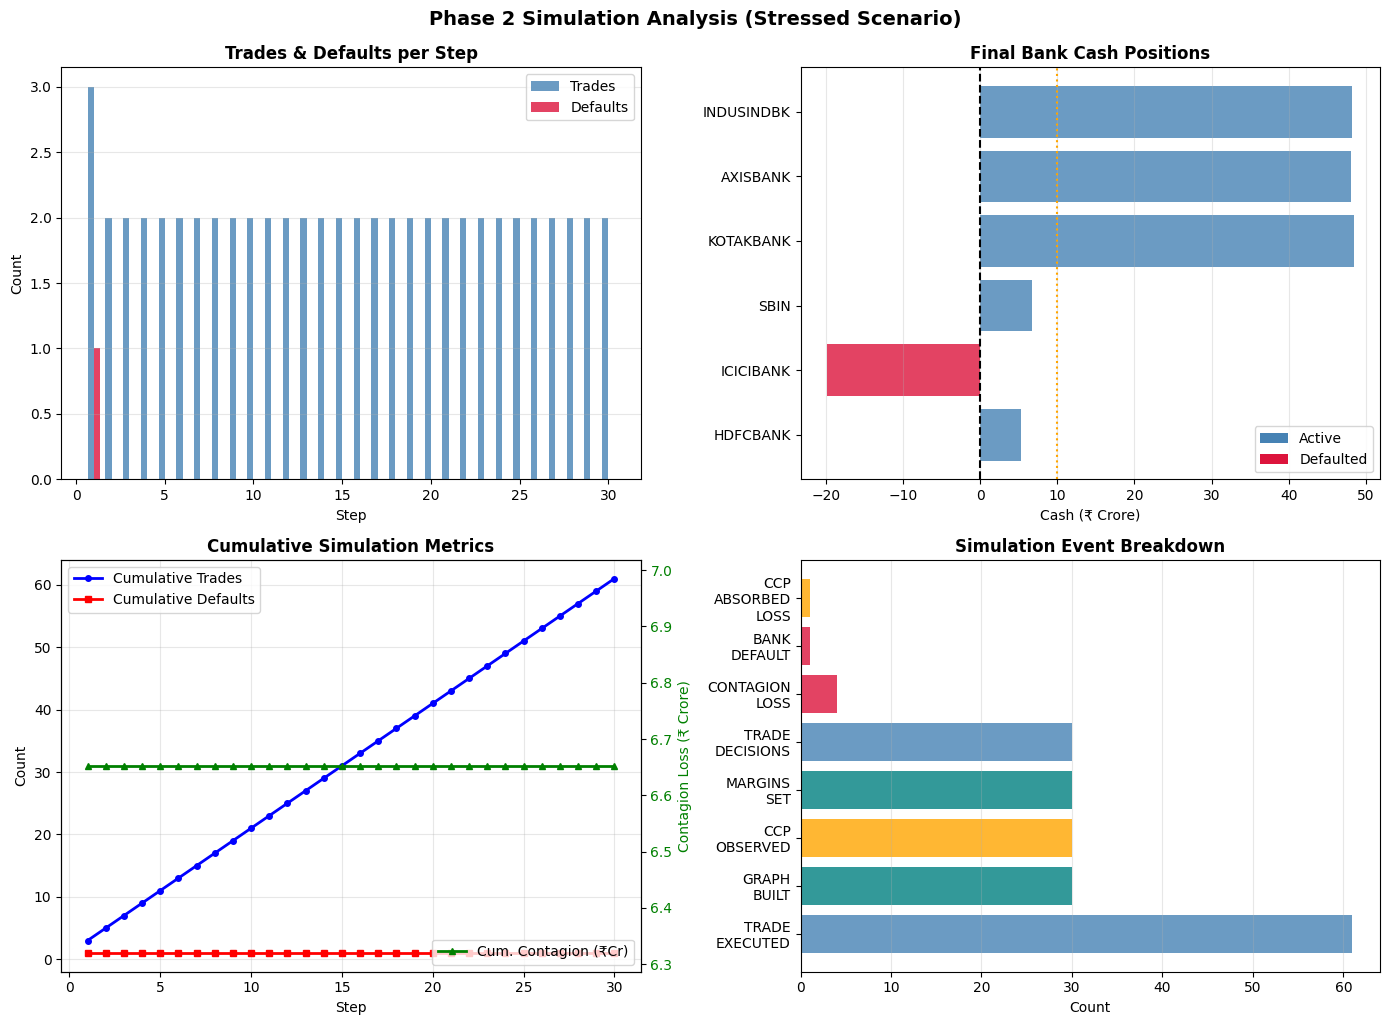


📊 SIMULATION SUMMARY
   Total steps: 30
   Total trades: 61
   Total defaults: 1
   Total contagion loss: ₹66,525,066
   CCP losses absorbed: ₹119,600,769
   CCP fund remaining: ₹9,880,399,231


In [10]:
# Cell 10: Visualization — System Dynamics (STRESSED)

print("=" * 60)
print("VISUALIZATION: SYSTEM DYNAMICS (STRESSED)")
print("=" * 60)

# Run fresh simulation for visualization
system.reset()

# Create stressed scenario again for visualization
for i, (ticker, bank) in enumerate(system.banks.items()):
    bank.portfolio = {ticker: 5000}
    if i == 0:
        bank.available_cash = 50_000_000  # Low cash → SELL
    elif i == 1:
        bank.available_cash = -200_000_000  # Negative → DEFAULT
    elif i == 2:
        bank.available_cash = 80_000_000  # Low → SELL
    else:
        bank.available_cash = 500_000_000  # Normal

results = system.run_simulation(
    start_date=pd.Timestamp('2022-06-20'),
    num_steps=30,
    verbose=False
)

# Create visualization
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Extract data
steps = [r['step'] for r in results]
trades = [r['trades_executed'] for r in results]
defaults = [len(r['defaults']) for r in results]
contagion = [r['total_contagion_loss'] / 1e7 for r in results]  # In crores

# Plot 1: Trades & Defaults per Step
ax1 = axes[0, 0]
width = 0.35
x = np.array(steps)
ax1.bar(x - width/2, trades, width, color='steelblue', alpha=0.8, label='Trades')
ax1.bar(x + width/2, defaults, width, color='crimson', alpha=0.8, label='Defaults')
ax1.set_xlabel('Step', fontsize=10)
ax1.set_ylabel('Count', fontsize=10)
ax1.set_title('Trades & Defaults per Step', fontsize=12, fontweight='bold')
ax1.legend()
ax1.grid(axis='y', alpha=0.3)

# Plot 2: Bank Cash Positions (Final)
ax2 = axes[0, 1]
bank_cash = [b.available_cash / 1e7 for b in system.banks.values()]  # In crores
bank_names = [t.replace('.NS', '') for t in system.banks.keys()]
colors = ['crimson' if system.banks[t+'.NS'].is_defaulted else 'steelblue' 
          for t in bank_names]

bars = ax2.barh(bank_names, bank_cash, color=colors, alpha=0.8)
ax2.axvline(x=0, color='black', linestyle='--', linewidth=1.5)
ax2.axvline(x=10, color='orange', linestyle=':', linewidth=1.5, label='Low Cash Threshold')
ax2.set_xlabel('Cash (₹ Crore)', fontsize=10)
ax2.set_title('Final Bank Cash Positions', fontsize=12, fontweight='bold')
ax2.grid(axis='x', alpha=0.3)

from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='steelblue', label='Active'),
                   Patch(facecolor='crimson', label='Defaulted')]
ax2.legend(handles=legend_elements, loc='lower right')

# Plot 3: Cumulative Metrics
ax3 = axes[1, 0]
cum_trades = np.cumsum(trades)
cum_defaults = np.cumsum(defaults)
cum_contagion = np.cumsum(contagion)

ax3.plot(steps, cum_trades, 'b-o', markersize=4, linewidth=2, label='Cumulative Trades')
ax3.plot(steps, cum_defaults, 'r-s', markersize=4, linewidth=2, label='Cumulative Defaults')

ax3_twin = ax3.twinx()
ax3_twin.plot(steps, cum_contagion, 'g-^', markersize=4, linewidth=2, label='Cum. Contagion (₹Cr)')
ax3_twin.set_ylabel('Contagion Loss (₹ Crore)', color='green', fontsize=10)
ax3_twin.tick_params(axis='y', labelcolor='green')

ax3.set_xlabel('Step', fontsize=10)
ax3.set_ylabel('Count', fontsize=10)
ax3.set_title('Cumulative Simulation Metrics', fontsize=12, fontweight='bold')
ax3.legend(loc='upper left')
ax3_twin.legend(loc='lower right')
ax3.grid(alpha=0.3)

# Plot 4: Event Type Breakdown
ax4 = axes[1, 1]
event_types = {}
for event in system.simulation_log:
    event_types[event.event_type] = event_types.get(event.event_type, 0) + 1

# Filter to interesting events and sort
interesting_events = ['TRADE_EXECUTED', 'BANK_DEFAULT', 'CONTAGION_LOSS', 
                      'CCP_ABSORBED_LOSS', 'MARKET_HALT', 'GRAPH_BUILT']
filtered_events = {k: v for k, v in event_types.items() if k in interesting_events or v > 5}
sorted_events = sorted(filtered_events.items(), key=lambda x: x[1], reverse=True)[:8]

event_names = [e[0].replace('_', '\n') for e in sorted_events]
event_counts = [e[1] for e in sorted_events]

colors_events = []
for name, _ in sorted_events:
    if 'DEFAULT' in name or 'CONTAGION' in name:
        colors_events.append('crimson')
    elif 'TRADE' in name:
        colors_events.append('steelblue')
    elif 'CCP' in name:
        colors_events.append('orange')
    else:
        colors_events.append('teal')

ax4.barh(event_names, event_counts, color=colors_events, alpha=0.8)
ax4.set_xlabel('Count', fontsize=10)
ax4.set_title('Simulation Event Breakdown', fontsize=12, fontweight='bold')
ax4.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.suptitle('Phase 2 Simulation Analysis (Stressed Scenario)', fontsize=14, fontweight='bold', y=1.02)
plt.show()

# Summary stats
print("\n" + "=" * 60)
print("📊 SIMULATION SUMMARY")
print("=" * 60)
print(f"   Total steps: {len(results)}")
print(f"   Total trades: {sum(trades)}")
print(f"   Total defaults: {sum(defaults)}")
print(f"   Total contagion loss: ₹{sum(contagion) * 1e7:,.0f}")
print(f"   CCP losses absorbed: ₹{system.ccp.total_losses_absorbed:,.0f}")
print(f"   CCP fund remaining: ₹{system.ccp.default_fund:,.0f}")

In [11]:
# Cell 11: FINAL TEST SUMMARY

print("\n")
print("=" * 60)
print("              PHASE 2 VALIDATION SUMMARY")
print("=" * 60)

passed = sum(1 for _, p in test_results if p)
failed = sum(1 for _, p in test_results if not p)
total = len(test_results)

print(f"\n{'Test':<30} {'Status':<10}")
print("-" * 40)
for name, passed_test in test_results:
    status = "✅ PASS" if passed_test else "❌ FAIL"
    print(f"{name:<30} {status:<10}")

print("-" * 40)
print(f"\n📊 Results: {passed}/{total} tests passed ({100*passed/total:.0f}%)")

if failed == 0:
    print("   ALL TESTS PASSED - PHASE 2 VALIDATED!")
else:
    print(f"\n⚠️ {failed} test(s) failed - review the output above for details")

print("\n" + "=" * 60)
print("Key Insights:")
print("-" * 60)
print("• Trade execution: Banks sell assets when cash is low")
print("• Default detection: Banks with negative cash are marked defaulted")
print("• Contagion: Losses propagate through network edges to neighbors")
print("• Market halt: Exchanges halt when VIX exceeds threshold")
print("• CCP: Absorbs residual losses up to its default fund capacity")
print("=" * 60)



              PHASE 2 VALIDATION SUMMARY

Test                           Status    
----------------------------------------
Initialization                 ✅ PASS    
Trade Execution                ✅ PASS    
Default Detection              ✅ PASS    
Contagion Propagation          ✅ PASS    
Market Halt                    ✅ PASS    
CCP Loss Absorption            ✅ PASS    
----------------------------------------

📊 Results: 6/6 tests passed (100%)
   ALL TESTS PASSED - PHASE 2 VALIDATED!

Key Insights:
------------------------------------------------------------
• Trade execution: Banks sell assets when cash is low
• Default detection: Banks with negative cash are marked defaulted
• Contagion: Losses propagate through network edges to neighbors
• Market halt: Exchanges halt when VIX exceeds threshold
• CCP: Absorbs residual losses up to its default fund capacity
